In [8]:
from typing import List
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from ccxt.binance import binance
from ccxt.hyperliquid import hyperliquid
from ccxt.lighter import lighter

from siglab_py.util.market_data_util import fetch_candles
from siglab_py.util.analytic_util import compute_candles_stats

VALIDATION_MAX_GAPS = 20

In [2]:
start_date = datetime(2026, 5,1)
end_date = datetime(2026,5,29,0,0,0)
exchange = lighter()
candle_size = "1h"

## Fetch Candles and Calculate TA

In [ ]:
all_candles_w_ta = {}
all_orderbooks = {}
crypto_tickers = [ "BTC/USDC:USDC", "ETH/USDC:USDC", "SOL/USDC:USDC", "DOGE/USDC:USDC", "HYPE/USDC:USDC" ]
commodities_tickers = [ "XAU/USDC:USDC", "XAG/USDC:USDC" ]
tradfi_tickers = [ "AMZN/USDC:USDC", "GOOGL/USDC:USDC", "META/USDC:USDC", "MSFT/USDC:USDC", "MSTR/USDC:USDC", "TSLA/USDC:USDC", "NVDA/USDC:USDC", "QQQ/USDC:USDC", "SPY/USDC:USDC" ]
fx_tickers = [ "EURUSD/USDC:USDC", "GBPUSD/USDC:USDC", "AUDUSD/USDC:USDC", "NZDUSD/USDC:USDC", "USDJPY/USDC:USDC", "USDCHF/USDC:USDC", "USDCAD/USDC:USDC" ]
tickers = fx_tickers + crypto_tickers + commodities_tickers + tradfi_tickers
for ticker in tickers:
    candles = fetch_candles(
                                                    start_ts=int(start_date.timestamp()), 
                                                    end_ts=int(end_date.timestamp()), 
                                                    exchange=exchange, normalized_symbols=[ticker], 
                                                    candle_size = candle_size, 
                                                    num_candles_limit = 100,
                                                    validation_max_gaps = VALIDATION_MAX_GAPS, # some newly listed FX pairs gaps
                                                    logger = None
                                                )
    pd_candles = candles[ticker]
    compute_candles_stats(
            pd_candles=pd_candles,
            boillenger_std_multiples=2,
            sliding_window_how_many_candles=24,
            validation_max_gaps = VALIDATION_MAX_GAPS, # some newly listed FX pairs gaps
            pypy_compat=False
        )

    all_candles_w_ta[ticker] = pd_candles

    print(f"Done fetch candles + calculate TA for {ticker}")

    all_orderbooks[ticker] = exchange.fetch_order_book(symbol=ticker)
    all_orderbooks[ticker]['timestamp'] = all_orderbooks[ticker]['timestamp'] if all_orderbooks[ticker]['timestamp'] else datetime.now().timestamp() # in seconds

# ATR

### Crypto + Commodities

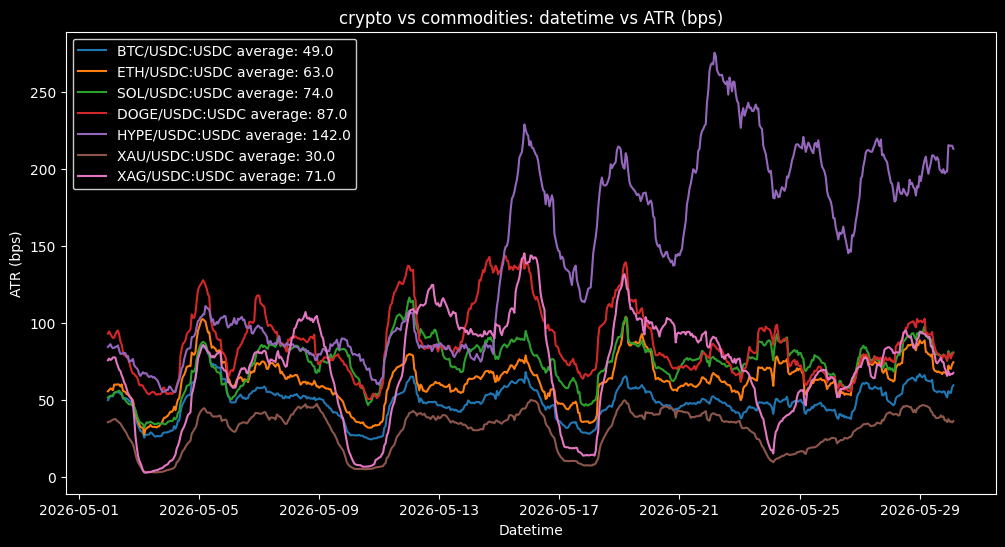

In [34]:
NUM_DAYS = 24*90
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(crypto_tickers + commodities_tickers)))

for i, ticker in enumerate(crypto_tickers + commodities_tickers):
    pd_candles = all_candles_w_ta[ticker]
    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(selected['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'crypto vs commodities: datetime vs ATR (bps)')
plt.show()

#### Chops analysis

In [ ]:
pd_candles

,exchange,symbol,timestamp_ms,open,high,low,close,volume,datetime,datetime_utc,...,normalized_hurst_exp_slope_min,normalized_hurst_exp_slope_max,normalized_hurst_exp_slope_idmin,normalized_hurst_exp_slope_idmax,fib_0.618_short_periods,fib_0.618_long_periods,gap_close_vs_ema,gap_close_vs_ema_percent,close_above_or_below_ema,close_vs_ema_inflection
0,Lighter,SPY/USDC:USDC,1777564800000,714.14,714.73,713.60,713.77,15.6525,2026-05-01 00:00:00,2026-04-30 16:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,None,0.0
1,Lighter,SPY/USDC:USDC,1777568400000,713.77,716.19,713.77,716.19,57.5300,2026-05-01 01:00:00,2026-04-30 17:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,2.226400,0.310867,above,NaN
2,Lighter,SPY/USDC:USDC,1777572000000,716.19,718.00,716.19,717.88,382.3419,2026-05-01 02:00:00,2026-04-30 18:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,3.603088,0.501907,above,NaN
3,Lighter,SPY/USDC:USDC,1777575600000,717.88,719.14,717.86,718.40,91.7222,2026-05-01 03:00:00,2026-04-30 19:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,3.793241,0.528012,above,NaN
4,Lighter,SPY/USDC:USDC,1777579200000,718.40,719.13,717.96,718.85,112.5396,2026-05-01 04:00:00,2026-04-30 20:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,3.903782,0.543059,above,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692,Lighter,SPY/USDC:USDC,1780066800000,755.40,756.92,755.40,755.90,98.1030,2026-05-29 23:00:00,2026-05-29 15:00:00+00:00,...,-0.580219,1.0,692.0,589.0,755.59928,754.90094,1.428007,0.188915,above,NaN
693,Lighter,SPY/USDC:USDC,1780070400000,755.90,757.23,755.78,756.10,21.0052,2026-05-30 00:00:00,2026-05-29 16:00:00+00:00,...,-0.602418,1.0,693.0,589.0,755.82176,754.90094,1.497767,0.198091,above,NaN
694,Lighter,SPY/USDC:USDC,1780074000000,756.10,756.47,755.00,755.00,23.1782,2026-05-30 01:00:00,2026-05-29 17:00:00+00:00,...,-0.618808,1.0,694.0,589.0,756.14948,754.90094,0.365945,0.048470,above,NaN
695,Lighter,SPY/USDC:USDC,1780077600000,755.00,756.26,755.00,755.00,47.7584,2026-05-30 02:00:00,2026-05-29 18:00:00+00:00,...,-0.628831,1.0,695.0,589.0,756.14948,755.01836,0.336670,0.044592,above,NaN


In [19]:
ticker = "XAG/USDC:USDC"
pd_candles = all_candles_w_ta[ticker]
pd_candles_above_ema = pd_candles[pd_candles.close>=pd_candles.ema_close]
pd_candles_below_ema = pd_candles[pd_candles.close<pd_candles.ema_close]

#### Smooth Trend ride

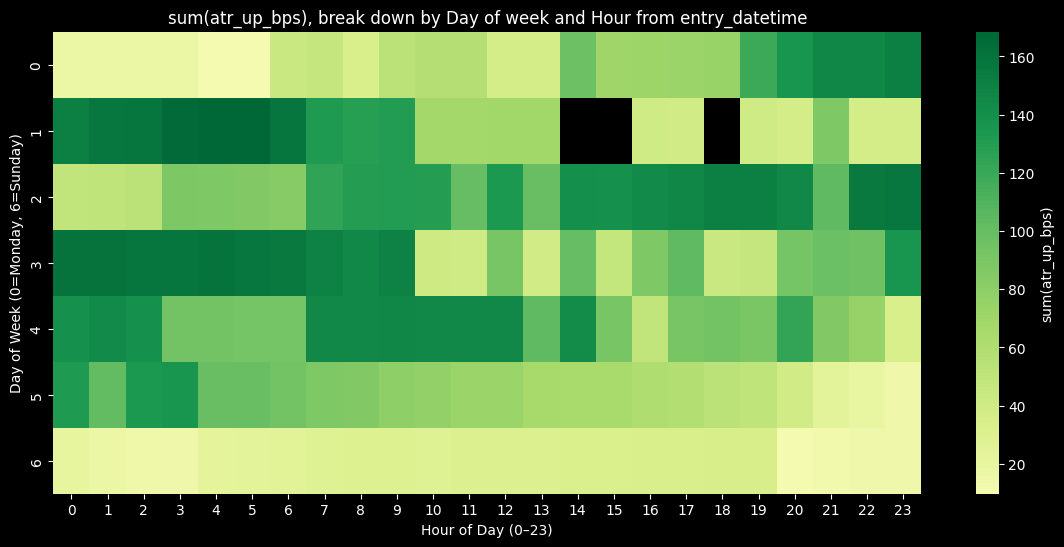

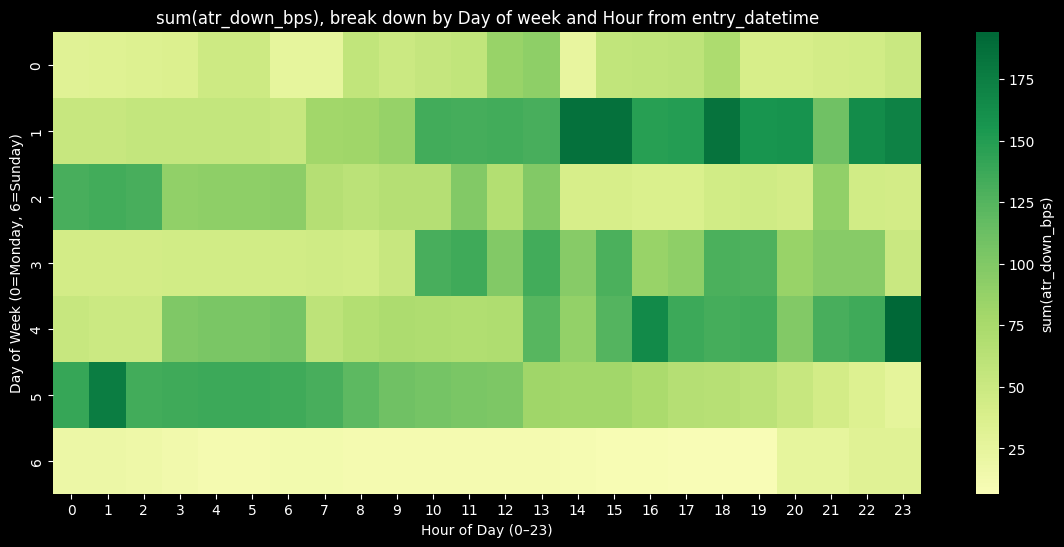

In [20]:
# UP trend
grouped = pd_candles_above_ema.groupby(['dayofweek', 'hour']).agg(
    simple_count=('datetime', 'size'),
    sum_atr_bps=('atr_bps', 'sum'),
    sum_atr_up_bps=('atr_up_bps', 'sum'),
    sum_atr_down_bps=('atr_down_bps', 'sum'),
).reset_index()
heatmap_data = grouped.pivot(index='dayofweek', columns='hour', values='sum_atr_up_bps')

plt.figure(figsize=(14, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

sns.heatmap(heatmap_data, annot=False, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'sum(atr_up_bps), break down by Day of week and Hour from entry_datetime'})

ax.set_title('sum(atr_up_bps), break down by Day of week and Hour from entry_datetime', color='white')
ax.set_xlabel('Hour of Day (0–23)', color='white')
ax.set_ylabel('Day of Week (0=Monday, 6=Sunday)', color='white')
ax.tick_params(colors='white')
cbar = ax.collections[0].colorbar
cbar.set_label('sum(atr_up_bps)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.show()

# DOWN trend
grouped = pd_candles_below_ema.groupby(['dayofweek', 'hour']).agg(
    simple_count=('datetime', 'size'),
    sum_atr_bps=('atr_bps', 'sum'),
    sum_atr_up_bps=('atr_up_bps', 'sum'),
    sum_atr_down_bps=('atr_down_bps', 'sum'),
).reset_index()
heatmap_data = grouped.pivot(index='dayofweek', columns='hour', values='sum_atr_down_bps')

plt.figure(figsize=(14, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

sns.heatmap(heatmap_data, annot=False, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'sum(atr_down_bps), break down by Day of week and Hour from entry_datetime'})

ax.set_title('sum(atr_down_bps), break down by Day of week and Hour from entry_datetime', color='white')
ax.set_xlabel('Hour of Day (0–23)', color='white')
ax.set_ylabel('Day of Week (0=Monday, 6=Sunday)', color='white')
ax.tick_params(colors='white')
cbar = ax.collections[0].colorbar
cbar.set_label('sum(atr_down_bps)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.show()

#### Counter Trend Whips

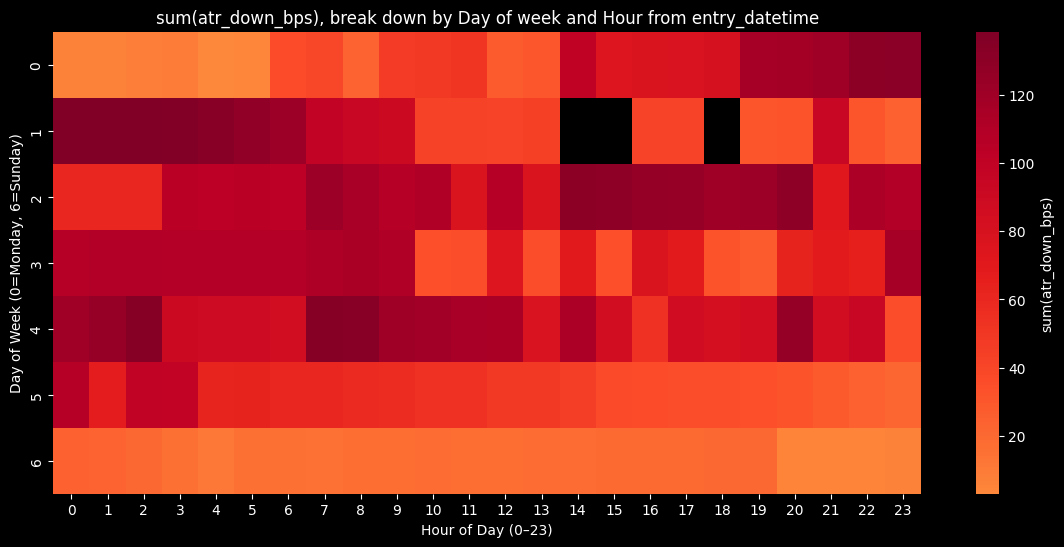

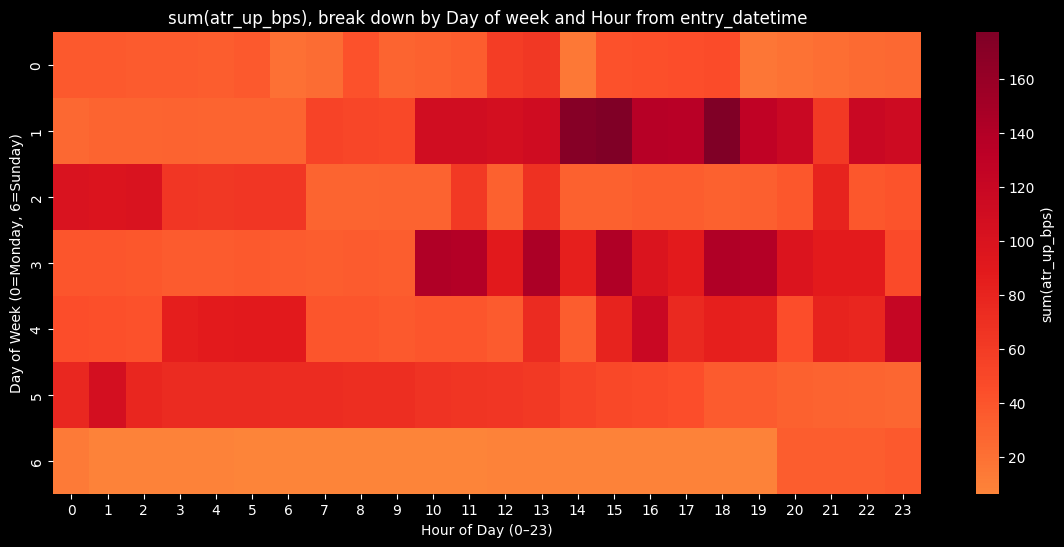

In [27]:
# UP trend
grouped = pd_candles_above_ema.groupby(['dayofweek', 'hour']).agg(
    simple_count=('datetime', 'size'),
    sum_atr_bps=('atr_bps', 'sum'),
    sum_atr_up_bps=('atr_up_bps', 'sum'),
    sum_atr_down_bps=('atr_down_bps', 'sum'),
).reset_index()
heatmap_data = grouped.pivot(index='dayofweek', columns='hour', values='sum_atr_down_bps')

plt.figure(figsize=(14, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

sns.heatmap(heatmap_data, annot=False, fmt='.2f', cmap='YlOrRd', center=0,
            cbar_kws={'label': 'sum(atr_down_bps), break down by Day of week and Hour from entry_datetime'})

ax.set_title('sum(atr_down_bps), break down by Day of week and Hour from entry_datetime', color='white')
ax.set_xlabel('Hour of Day (0–23)', color='white')
ax.set_ylabel('Day of Week (0=Monday, 6=Sunday)', color='white')
ax.tick_params(colors='white')
cbar = ax.collections[0].colorbar
cbar.set_label('sum(atr_down_bps)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.show()

# DOWN trend
grouped = pd_candles_below_ema.groupby(['dayofweek', 'hour']).agg(
    simple_count=('datetime', 'size'),
    sum_atr_bps=('atr_bps', 'sum'),
    sum_atr_up_bps=('atr_up_bps', 'sum'),
    sum_atr_down_bps=('atr_down_bps', 'sum'),
).reset_index()
heatmap_data = grouped.pivot(index='dayofweek', columns='hour', values='sum_atr_up_bps')

plt.figure(figsize=(14, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

sns.heatmap(heatmap_data, annot=False, fmt='.2f', cmap='YlOrRd', center=0,
            cbar_kws={'label': 'sum(atr_up_bps), break down by Day of week and Hour from entry_datetime'})

ax.set_title('sum(atr_up_bps), break down by Day of week and Hour from entry_datetime', color='white')
ax.set_xlabel('Hour of Day (0–23)', color='white')
ax.set_ylabel('Day of Week (0=Monday, 6=Sunday)', color='white')
ax.tick_params(colors='white')
cbar = ax.collections[0].colorbar
cbar.set_label('sum(atr_up_bps)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.show()

#### Flow snapshot

In [42]:
max_slippage_bps = 2

tip_of_the_book = []
for ticker in tickers:
    ob = all_orderbooks[ticker]
    bids = ob['bids']
    asks = ob['asks'] 
    best_bid = max([ bid[0] for bid in bids ])
    best_ask = min([ ask[0] for ask in asks ])
    best_bid_volume_base_ccy = sum([ bid[1] for bid in bids if bid[0]>=best_bid*(1 - max_slippage_bps/10000) ])
    best_bid_volume_usd = int(best_bid_volume_base_ccy * best_bid)
    best_ask_volume_base_ccy = sum([ ask[1] for ask in asks if ask[0]<=best_ask*(1 + max_slippage_bps/10000)])
    best_ask_volume_usd = int(best_ask_volume_base_ccy * best_ask)

    tip_of_the_book.append({
            'exchange' : exchange.name,
            'ticker' : ticker,
            'best_bid' : best_bid,
            'best_ask' : best_ask,
            'best_bid_volume_base_ccy' : round(best_bid_volume_base_ccy, 2),
            'best_bid_volume_usd' : best_bid_volume_usd,
            'best_ask_volume_base_ccy' : round(best_ask_volume_base_ccy, 2),
            'best_ask_volume_usd' : best_ask_volume_usd,
            'total_volume_usd' : best_bid_volume_usd + best_ask_volume_usd,
            'min_volume_usd' : min(best_bid_volume_usd, best_ask_volume_usd),
            'timestamp' : datetime.fromtimestamp(ob['timestamp'])
        }
    )

pd_tip_of_the_book = pd.DataFrame(tip_of_the_book)
pd_tip_of_the_book.sort_values(
    by=['min_volume_usd'], 
    ascending=False,
    inplace=True
)

pd_tip_of_the_book_styled = pd_tip_of_the_book[['exchange', 'ticker', 'best_bid_volume_usd', 'best_ask_volume_usd', 'min_volume_usd', 'timestamp']].style.format({
    'best_bid_volume_usd': '{:,.0f}',
    'best_ask_volume_usd': '{:,.0f}',
    'min_volume_usd' : '{:,.0f}',
})
pd_tip_of_the_book_styled

,exchange,ticker,best_bid_volume_usd,best_ask_volume_usd,min_volume_usd,timestamp
7,Lighter,BTC/USDC:USDC,"1,225,550","1,323,001","1,225,550",2026-05-30 15:08:04.701712
8,Lighter,ETH/USDC:USDC,"1,386,801","1,224,064","1,224,064",2026-05-30 15:08:20.468976
12,Lighter,XAU/USDC:USDC,"85,534","67,213","67,213",2026-05-30 15:09:24.056343
9,Lighter,SOL/USDC:USDC,"240,300","36,244","36,244",2026-05-30 15:08:36.498535
13,Lighter,XAG/USDC:USDC,"23,014","38,984","23,014",2026-05-30 15:09:40.503875
11,Lighter,HYPE/USDC:USDC,"14,057","47,681","14,057",2026-05-30 15:09:08.131223
22,Lighter,SPY/USDC:USDC,"106,474","13,563","13,563",2026-05-30 15:12:09.558721
17,Lighter,MSFT/USDC:USDC,"12,004","12,994","12,004",2026-05-30 15:10:47.010974
0,Lighter,EURUSD/USDC:USDC,"27,794","7,620","7,620",2026-05-30 15:06:29.653730
10,Lighter,DOGE/USDC:USDC,"8,595","5,108","5,108",2026-05-30 15:08:52.339683


### ATR histogram

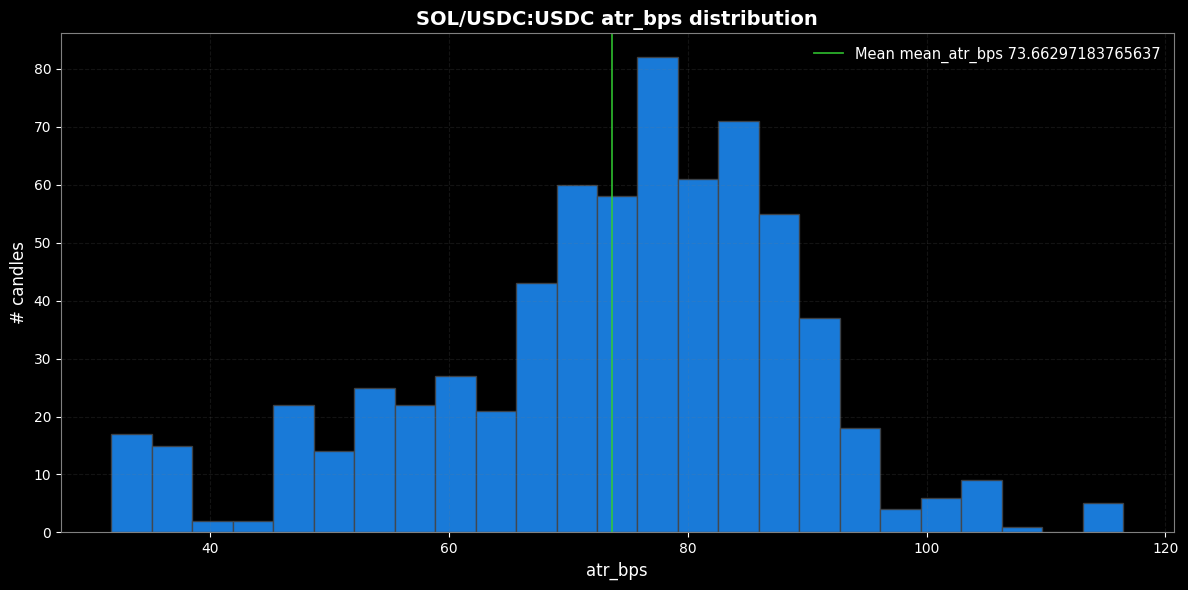

In [36]:
ticker = "SOL/USDC:USDC"
pd_candles = all_candles_w_ta[ticker]

plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.hist(
    pd_candles['atr_bps'],
    
    bins=25,
    edgecolor='#444444',
    alpha=0.85,
    color='dodgerblue'
)

mean_atr_bps = pd_candles['atr_bps'].mean()
plt.axvline(mean_atr_bps, color='limegreen', linestyle='-', linewidth=1.3, alpha=0.85,
            label=f'Mean mean_atr_bps {mean_atr_bps}')

plt.title(f'{ticker} atr_bps distribution', 
          fontsize=14, fontweight='bold', color='white')
plt.xlabel('atr_bps', fontsize=12, color='white')
plt.ylabel('# candles', fontsize=12, color='white')

plt.grid(True, alpha=0.15, linestyle='--', color='gray')
plt.legend(loc='upper right', frameon=False, fontsize=10.5, labelcolor='white')

ax.tick_params(colors='white', which='both')
ax.spines['bottom'].set_color('gray')
ax.spines['top'].set_color('gray')
ax.spines['left'].set_color('gray')
ax.spines['right'].set_color('gray')

plt.tight_layout()
plt.show()

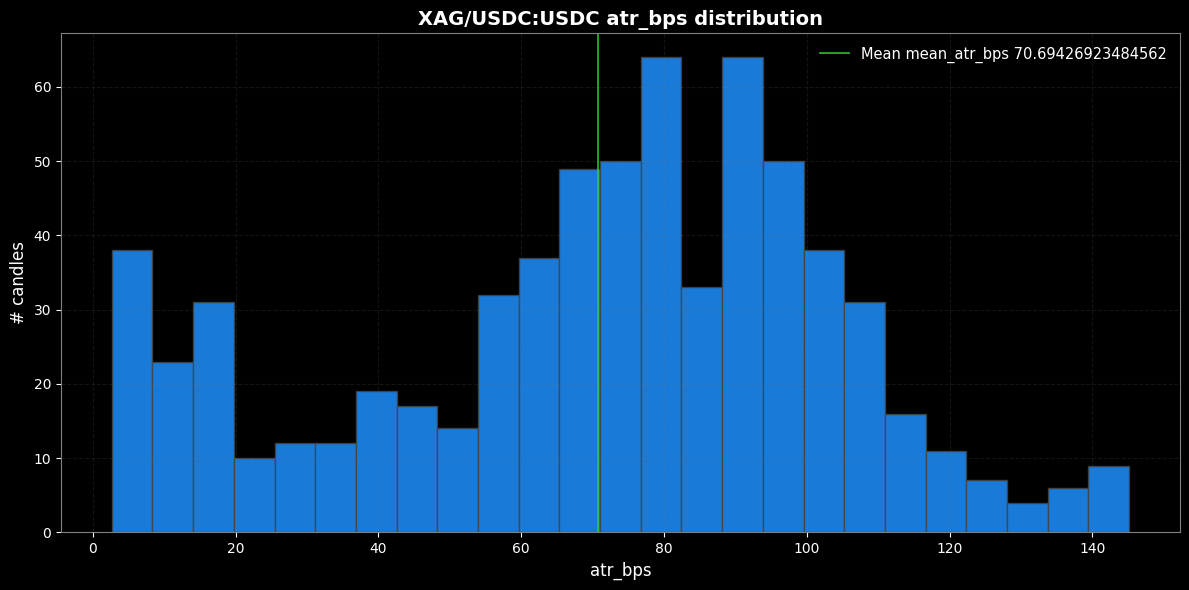

In [37]:
ticker = "XAG/USDC:USDC"
pd_candles = all_candles_w_ta[ticker]

plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.hist(
    pd_candles['atr_bps'],
    
    bins=25,
    edgecolor='#444444',
    alpha=0.85,
    color='dodgerblue'
)

mean_atr_bps = pd_candles['atr_bps'].mean()
plt.axvline(mean_atr_bps, color='limegreen', linestyle='-', linewidth=1.3, alpha=0.85,
            label=f'Mean mean_atr_bps {mean_atr_bps}')

plt.title(f'{ticker} atr_bps distribution', 
          fontsize=14, fontweight='bold', color='white')
plt.xlabel('atr_bps', fontsize=12, color='white')
plt.ylabel('# candles', fontsize=12, color='white')

plt.grid(True, alpha=0.15, linestyle='--', color='gray')
plt.legend(loc='upper right', frameon=False, fontsize=10.5, labelcolor='white')

ax.tick_params(colors='white', which='both')
ax.spines['bottom'].set_color('gray')
ax.spines['top'].set_color('gray')
ax.spines['left'].set_color('gray')
ax.spines['right'].set_color('gray')

plt.tight_layout()
plt.show()

### Tradfi

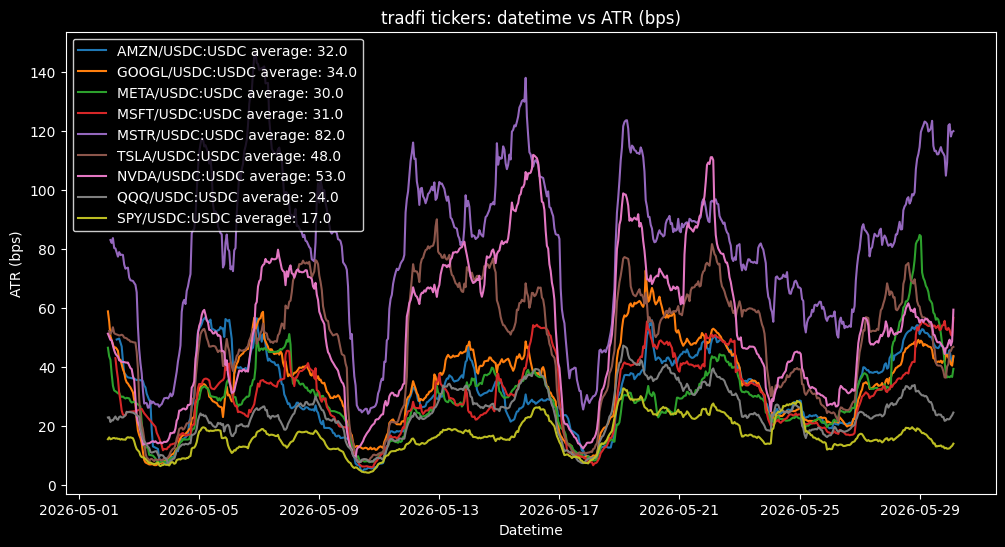

In [38]:
NUM_DAYS = 24*365
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(tradfi_tickers)))

for i, ticker in enumerate(tradfi_tickers):
    pd_candles = all_candles_w_ta[ticker]
    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(selected['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'tradfi tickers: datetime vs ATR (bps)')
plt.show()

### FX

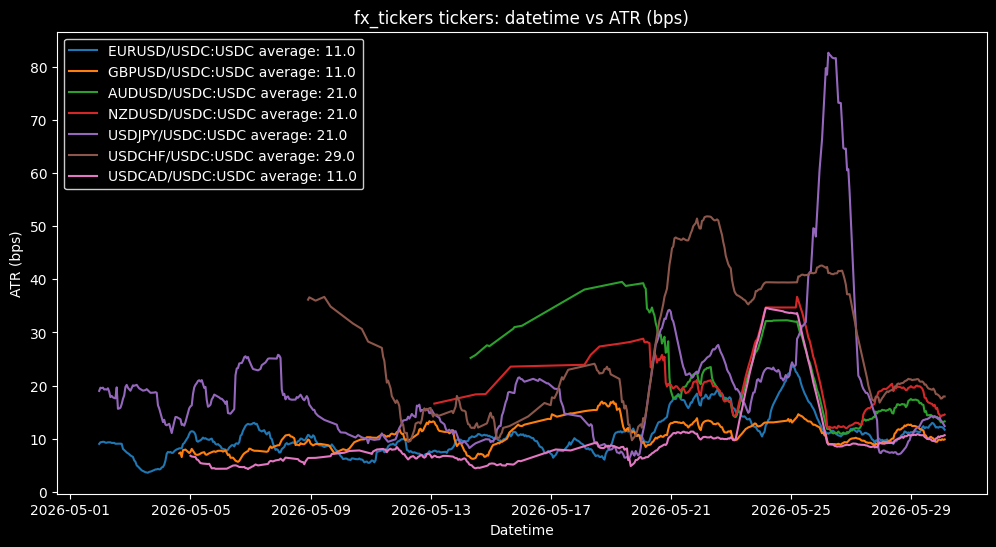

In [39]:
NUM_DAYS = 24*365
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(fx_tickers)))

for i, ticker in enumerate(fx_tickers):
    pd_candles = all_candles_w_ta[ticker]
    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(selected['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'fx_tickers tickers: datetime vs ATR (bps)')
plt.show()